#Customer Review Analyzer

**Domain:** Retail / E-commerce -- NLP

**Dataset:** Women's E-Commerce Clothing Reviews -- https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews

**Skills:** Sentiment Analysis, Topic Extraction, Text Analytics, NLP, LLM-Based Analysis

**Tools:** Python, HuggingFace Transformers, Scikit-learn (TF-IDF/LDA), Cerebras / Groq / Ollama (free tier, via shared call_llm())

---

### Problem Statement
A retailer has thousands of unread product reviews containing valuable signal about product quality, sizing issues, and feature requests -- but no one has time to read them manually. They need this unstructured feedback converted into a structured, actionable summary.

In [1]:
!pip install -q kagglehub sentence-transformers transformers

### Setup

In [2]:
import pandas as pd
import numpy as np
# ---- AI setup: same pattern for every project, so it's one thing to remember ----
# we try cerebras first (biggest free daily limit), then groq, then a local ollama model
# if all 3 are down for some reason we just return a message instead of crashing the whole script
import os
from getpass import getpass
import requests
from openai import OpenAI
import warnings
warnings.filterwarnings("ignore")

# asking for api keys only if they are not already set, and using getpass so the key
# does not get printed on screen or saved inside the notebook by accident
if not os.environ.get("CEREBRAS_API_KEY"):
    os.environ["CEREBRAS_API_KEY"] = getpass("Enter your Cerebras API key: ")
if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

cerebras_client = OpenAI(api_key=os.environ["CEREBRAS_API_KEY"], base_url="https://api.cerebras.ai/v1")
groq_client = OpenAI(api_key=os.environ["GROQ_API_KEY"], base_url="https://api.groq.com/openai/v1")
OLLAMA_URL = "http://localhost:11434/api/generate"

def call_llm(prompt):
    # step 1: try cerebras, it has the biggest free tier (1M tokens/day)
    try:
        response = cerebras_client.chat.completions.create(
            model="gpt-oss-120b",
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print("cerebras failed:", e)

    # step 2: cerebras down or key wrong, try groq next
    try:
        response = groq_client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print("groq failed:", e)

    # step 3: last resort, try a local ollama model if one happens to be running
    try:
        resp = requests.post(OLLAMA_URL, json={"model": "llama3", "prompt": prompt, "stream": False})
        resp.raise_for_status()
        return resp.json()["response"].strip()
    except Exception as e:
        print("ollama failed too:", e)
        return "AI call failed, all 3 options did not work"

from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)
        df = pd.read_csv(full_path)
        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_reviews(n_rows=1500):
    np.random.seed(6)
    good = ["love this product, fits perfectly and great quality",
            "amazing fabric, exactly as pictured, will buy again",
            "super comfortable and true to size"]
    bad = ["fabric feels cheap and it ran way too small",
           "sizing is completely off, had to return it",
           "shipping took forever and the item arrived damaged"]
    depts = ['Tops', 'Dresses', 'Bottoms', 'Jackets', 'Intimates']
    rows = []
    for _ in range(n_rows):
        is_bad = np.random.rand() < 0.3
        text = np.random.choice(bad if is_bad else good)
        rating = np.random.choice([1, 2]) if is_bad else np.random.choice([4, 5])
        rows.append({'Title': '', 'Review Text': text, 'Rating': rating,
                     'Department Name': np.random.choice(depts),
                     'Review Date': pd.Timestamp('2024-01-01') + pd.Timedelta(days=np.random.randint(0, 300))})
    return pd.DataFrame(rows)

Enter your Cerebras API key: ··········
Enter your Groq API key: ··········


### Step 1: Load & Clean

In [3]:
# 1. LOAD & CLEAN
df = load_dataset_safe('nicapotato/womens-ecommerce-clothing-reviews', 'Womens Clothing E-Commerce Reviews.csv',
                        make_fake_reviews, n_rows=1500)
if 'Review Text' not in df.columns:
    df = make_fake_reviews(1500)
df['full_text'] = df['Title'].fillna('') + '. ' + df['Review Text'].fillna('')
df = df[df['full_text'].str.strip().str.len() > 5]
df = df.sample(min(800, len(df)), random_state=42).reset_index(drop=True)  # keeping it small so sentiment scoring finishes in minutes, not forever

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
loaded real dataset from kaggle, 23486 rows


### Step 2: Sentiment Using A Free, Local Transformer Model

In [4]:
# 2. SENTIMENT USING A FREE, LOCAL TRANSFORMER MODEL (no api cost)
sentiment_pipe = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

def get_sentiment(text):
    result = sentiment_pipe(text[:512])[0]
    return result['score'] if result['label'] == 'POSITIVE' else -result['score']

df['sentiment_score'] = df['full_text'].apply(get_sentiment)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

### Step 3: Find Complaint Themes By Only Looking At Low-Rated Reviews

In [5]:
# 3. FIND COMPLAINT THEMES BY ONLY LOOKING AT LOW-RATED REVIEWS
negative_reviews = df[df['Rating'] <= 2]['full_text']
if len(negative_reviews) > 10:
    tfidf = TfidfVectorizer(max_features=500, stop_words='english', min_df=2)
    tfidf_matrix = tfidf.fit_transform(negative_reviews)
    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    lda.fit(tfidf_matrix)
    feature_names = tfidf.get_feature_names_out()
    for idx, topic in enumerate(lda.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-8:]]
        print(f"topic {idx}: {', '.join(top_words)}")

topic 0: coat, fits, loved, dress, felt, huge, fabric, like
topic 1: good, pretty, fabric, shirt, dresses, jeans, material, dress
topic 2: cute, pink, online, way, got, great, material, disappointing
topic 3: short, wear, shirt, small, like, fit, skirt, dress
topic 4: didn, like, small, disappointed, large, shoulders, size, dress


### Step 4: Use The Llm To Write A Human-Readable Summary Of Complaints

In [6]:
# 4. USE THE LLM TO WRITE A HUMAN-READABLE SUMMARY OF COMPLAINTS (our shared call_llm function)
sample_negative = negative_reviews.sample(min(30, len(negative_reviews)), random_state=42).tolist()
prompt = "Summarize the top 5 recurring complaints and top 3 feature requests from these reviews:\n\n" + \
         "\n---\n".join(sample_negative)
summary = call_llm(prompt)
print(summary)
with open('review_summary.txt', 'w') as f:
    f.write(summary)

cerebras failed: Error code: 402 - {'message': 'Payment required to access this resource. Visit your billing tab.', 'type': 'payment_required_error', 'param': 'quota', 'code': 'payment_required'}
**Top 5 recurring complaints (what customers keep grumbling about)**  

| # | Complaint | Frequency cue in the reviews | Why it hurts the shopper experience |
|---|-----------|------------------------------|--------------------------------------|
| 1️⃣ | **Fit is wildly off‑scale** – items run too large, are overly boxy/short, or flare in the wrong places (shoulder‑fat sleeves, “mushroom” tops, huge‑but‑short coats). | Mentioned in ≥ 12 reviews. | Customers can’t wear the piece, have to return it, and lose confidence in the brand’s size chart. |
| 2️⃣ **Fabric feels cheap or wrong** – chemical/“plastic” smell, excessive polyester, stiff or too‑stretchy material, rapid pilling, thin/see‑through texture. | Appears in ≥ 10 reviews. | The garment looks nice on the model but feels cheap in‑hand, le

### Step 5: Sentiment By Age Group + Per-Department Leaderboard

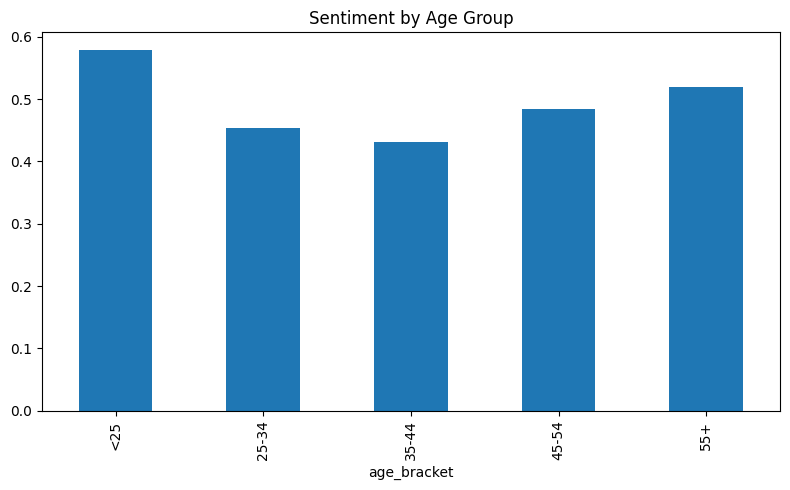

In [7]:
# 5. SENTIMENT BY AGE GROUP + PER-DEPARTMENT LEADERBOARD
# note: the real kaggle dataset doesn't actually have a review date column, so instead of a
# fake time trend we're looking at sentiment by age bracket, which the real data does support
if 'Age' in df.columns:
    df['age_bracket'] = pd.cut(df['Age'], [0, 25, 35, 45, 55, 100],
                                labels=['<25', '25-34', '35-44', '45-54', '55+'])
    sentiment_by_age = df.groupby('age_bracket')['sentiment_score'].mean()
    sentiment_by_age.plot(kind='bar', figsize=(8, 5), title='Sentiment by Age Group')
    plt.tight_layout()
    plt.savefig('sentiment_by_age.png')
    plt.show()

dept_leaderboard = df.groupby('Department Name')['sentiment_score'].mean().sort_values()
dept_leaderboard.to_csv('department_sentiment_leaderboard.csv')
df.to_csv('reviews_scored.csv', index=False)